# RISE feature extraction pipeline

This notebook demonstrates the complete workflow for extracting multifaceted fMRI features, using two HCP-YA subjects as examples. Features are calculated separately from time series processed without and with global signal regression (NGR and GSR). Each mode contains 189 features, giving 378 features in total.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "configs").is_dir():
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()
if not (PROJECT_ROOT / "configs").is_dir():
    raise FileNotFoundError("Run this notebook from the RISE repository root or pipeline directory")
from rise import (
    fetch_feature_names,
    extract_classical_metrics,
    extract_cortical_fc,
    extract_cortico_network_fc,
    extract_subcortical_cerebellar_fc,
    extract_functional_gradients,
    feature_basename,
    load_feature_config,
    read_subject_ids,
    summarize_hctsa_features,
    visualize_surface_map,
)


### Parameters and example subjects

The feature preset specifies the paths to the preprocessed data, atlas selection, imaging space, and parameters for feature extraction. The workflow is demonstrated using two HCP-YA subjects.

In [ ]:
CONFIG_FILE = PROJECT_ROOT / "configs" / "hcp_feature_parameters.jsonc"
config = load_feature_config(CONFIG_FILE)
subjects = read_subject_ids(*config["subject_files"])[:2]
modes = config["gsr_modes"]
figure_dir = Path(config["output_root"]) / "figures" / "feature_examples"
figure_dir.mkdir(parents=True, exist_ok=True)
print(f"Subjects: {subjects}")
print(f"Regression modes: {modes}")

FEATURE_NAMES_FILE = fetch_feature_names()
feature_names = pd.read_csv(FEATURE_NAMES_FILE)["Feature_name"].tolist()


def feature_index(feature_name):
    """Return a feature's column index within its feature group."""
    group = feature_name.split("__", 1)[0]
    group_names = [name for name in feature_names if name.startswith(group + "__")]
    if feature_name not in group_names:
        raise ValueError("Feature name not found: {}".format(feature_name))
    return group_names.index(feature_name)


def feature_title(feature_name):
    """Return a readable plot title without the regression-mode label."""
    return feature_name.replace("_GSR__", ": ").replace("_", " ")



### Cortical FC

Calculate FC between cortical parcels for subsequent functional gradient estimation.

In [ ]:
cortical_fc_outputs = {
    mode: extract_cortical_fc(subjects, config, mode, n_jobs=32)
    for mode in modes
}


### Functional gradients

Extract individual-aligned functional gradients from cortical parcel-wise FC matrices. The first 20 functional gradients are computed separately for time series with and without global signal regression (GSR).


In [ ]:
gradient_outputs = {
    mode: extract_functional_gradients(subjects, config, mode, n_jobs=32)
    for mode in modes
}


<Figure size 640x480 with 0 Axes>

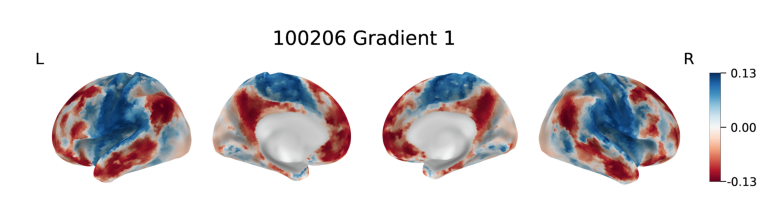

In [5]:
gradient_name = "GradAligned_GSR__Gradients1"
gradient_example = np.load(gradient_outputs["GSR"][subjects[0]][-1])
visualize_surface_map(
    gradient_example[:, feature_index(gradient_name)],
    config,
    f"{subjects[0]} Gradient 1",
    figure_dir / "gradient_example.png",
    cmap="RdBu",
)
plt.show()


### Cortico-network FC

Compute FC between each cortical parcel and the Yeo 7, Yeo 17, and 22 PFM networks, yielding 46 parcel-to-network connectivity features.

In [ ]:
network_outputs = {}
for mode in modes:
    network_outputs[mode] = {}
    for network_name in config["network_atlases"]:
        network_outputs[mode][network_name] = extract_cortico_network_fc(
            subjects, config, mode, network_name, n_jobs=32
        )


<Figure size 640x480 with 0 Axes>

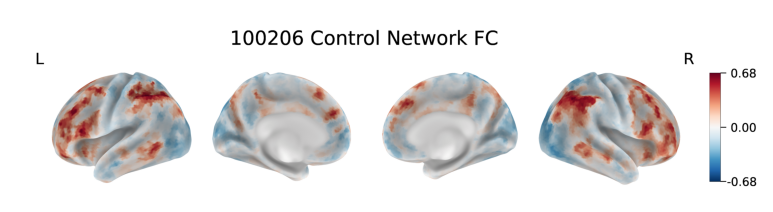

In [7]:
network_name = "Yeo7_GSR__Network_Control"
network_example = np.load(network_outputs["GSR"]["Yeo7"][subjects[0]][-1])
visualize_surface_map(
    network_example[:, feature_index(network_name)],
    config,
    f"{subjects[0]} Control Network FC",
    figure_dir / "cortico_network_example.png",
)
plt.show()


### Cortico-subcortical and cortico-cerebellar FC

Calculate FC between cortical parcels and the 54 regions of the Tian Subcortical Atlas (Scale IV), and between cortical parcels and the 17 networks of the Buckner cerebellar atlas, yielding 71 features.


In [ ]:
subcortical_outputs = {}
cerebellar_outputs = {}
for mode in modes:
    subcortical_outputs[mode] = extract_subcortical_cerebellar_fc(
        subjects, config, mode, config["subcortical_atlas"], "Tianye_subcortical_fc", n_jobs=32
    )
    cerebellar_outputs[mode] = extract_subcortical_cerebellar_fc(
        subjects, config, mode, config["cerebellar_atlas"], "Buckner_cerebellar_fc", n_jobs=32
    )


<Figure size 640x480 with 0 Axes>

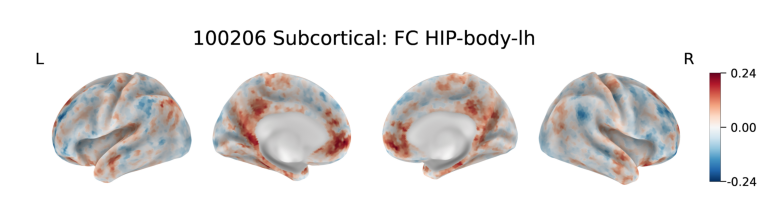

In [9]:
subcortical_name = "Subcortical_GSR__FC_HIP-body-lh"
subcortical_example = np.load(subcortical_outputs["GSR"][subjects[0]][-1])
visualize_surface_map(
    subcortical_example[:, feature_index(subcortical_name)],
    config,
    f"{subjects[0]} {feature_title(subcortical_name)}",
    figure_dir / "subcortical_example.png",
)
plt.show()

### Temporal dynamics

Convert the completed hctsa MAT files into labeled parcel-by-feature CSV files. The 49 refined temporal-dynamics features are summarized separately for NGR and GSR and averaged across runs.


In [ ]:
hctsa_outputs = {
    mode: summarize_hctsa_features(subjects, config, mode, n_jobs=32)
    for mode in modes
}


<Figure size 640x480 with 0 Axes>

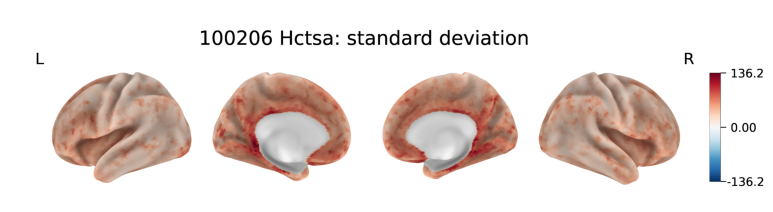

In [15]:
hctsa_name = "Hctsa_GSR__standard_deviation"
hctsa_example = pd.read_csv(hctsa_outputs["GSR"][subjects[0]][-1], index_col=0)
visualize_surface_map(
    hctsa_example.iloc[:, feature_index(hctsa_name)].to_numpy(),
    config,
    f"{subjects[0]} {feature_title(hctsa_name)}",
    figure_dir / "hctsa_example.png",
)
plt.show()


### Classical local metrics

Average the precomputed voxelwise ALFF, fractional ALFF (fALFF), and regional homogeneity (ReHo) maps within each cortical parcel, yielding 3 features.


In [ ]:
classical_outputs = {
    mode: extract_classical_metrics(subjects, config, mode, n_jobs=32)
    for mode in modes
}


<Figure size 640x480 with 0 Axes>

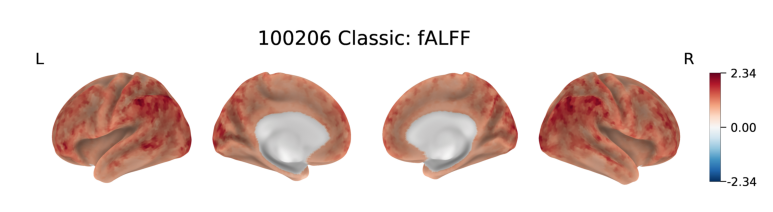

In [13]:
classic_name = "Classic_GSR__fALFF"
classic_metric = classic_name.split("__", 1)[1]
basename = feature_basename(config, "GSR")
classic_path = (
    Path(config["output_root"]) / "indiv" / subjects[0] / "func" / "mean" / "feature"
    / f"sub-{subjects[0]}_mean{basename}_feature-{classic_metric}.npy"
)
classic_example = np.load(classic_path).squeeze()

visualize_surface_map(
    classic_example,
    config,
    f"{subjects[0]} {feature_title(classic_name)}",
    figure_dir / "classic_metric_example.png",
)
plt.show()


### Output summary (189 features per preprocessing stream; 378 in total)

The final feature set contains 20 gradients, 46 parcel-to-network FC features, 71 cortico-subcortical/cerebellar FC features, 49 temporal dynamics features, and 3 classical local metrics. All features are computed separately for time series with and without global signal regression (GSR).

In [ ]:
feature_counts = pd.DataFrame(
    {
        "feature_category": [
            "Gradients",
            "Cortico-network FC",
            "Cortico-subcortical/cerebellar FC",
            "Temporal dynamics",
            "Classical local metrics",
        ],
        "count": [20, 46, 71, 49, 3],
    }
)
print(f"Features per mode: {feature_counts['count'].sum()}")
print(f"NGR + GSR features: {feature_counts['count'].sum() * len(modes)}")
display(feature_counts)

summary = []
for subject in subjects:
    feature_dir = Path(config["output_root"]) / "indiv" / subject / "func" / "mean" / "feature"
    for mode in modes:
        files = sorted(path.name for path in feature_dir.glob(f"*_{mode}_feature-*"))
        summary.append({"subject": subject, "mode": mode, "feature_files": len(files)})
pd.DataFrame(summary)


### One-step feature extraction

As an alternative to sequential category-specific extraction, all feature categories above can be computed in a single call following hctsa processing. Execute this cell to run the complete extraction pipeline.

In [ ]:
from rise import extract_all_features

all_feature_outputs = extract_all_features(
    subjects,
    config,
    modes=modes,
    n_jobs=32,
)
